# Titanic Survival Prediction (KNN + PCA)
Minimal workflow with noisy-column dropping, PCA, and k-fold tuning.


In [13]:
WEIGHTS_CANDIDATES = ["uniform", "distance"]
METRIC_CANDIDATES = ["euclidean", "manhattan"]

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier  
from sklearn.preprocessing import StandardScaler

SEED = 42
TEST_SIZE = 0.25
TARGET_COL = "Survived"
N_NEIGHBORS_CANDIDATES = [3, 5, 7, 9, 11]
CV_SPLITS = 5
PCA_VARIANCE = 0.95

DROP_COLS = [
    "PassengerId",
    "Name",
    "Ticket",
    "Cabin",
    "service_id",
    "booking_reference",
    "age_fare_ratio",
]

DATA_PATH = Path("titanic_augmented.csv")


In [14]:
np.random.seed(SEED)

df = pd.read_csv(DATA_PATH)
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

def preprocess(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # Drop noisy / high-cardinality columns before encoding.
    cols_to_drop = [c for c in DROP_COLS if c in train_df.columns]
    if cols_to_drop:
        train_df = train_df.drop(columns=cols_to_drop)
        test_df = test_df.drop(columns=cols_to_drop)

    cat_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns
    num_cols = [c for c in train_df.columns if c not in cat_cols]

    for col in num_cols:
        median_value = train_df[col].median()
        train_df[col] = train_df[col].fillna(median_value)
        test_df[col] = test_df[col].fillna(median_value)

    for col in cat_cols:
        mode_series = train_df[col].mode(dropna=True)
        fill_value = mode_series.iloc[0] if not mode_series.empty else "Unknown"
        train_df[col] = train_df[col].fillna(fill_value)
        test_df[col] = test_df[col].fillna(fill_value)

    train_df = pd.get_dummies(train_df, columns=cat_cols)
    test_df = pd.get_dummies(test_df, columns=cat_cols)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df)
    test_scaled = scaler.transform(test_df)

    # PCA to reduce dimensionality while keeping ~95% variance.
    pca = PCA(n_components=PCA_VARIANCE, svd_solver="full")
    train_pca = pca.fit_transform(train_scaled)
    test_pca = pca.transform(test_scaled)

    return train_pca, test_pca, int(pca.n_components_)


In [15]:
# K-Fold cross-validation for hyperparameter tuning (keeps test set untouched).
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)
tuning_results = []

for k in N_NEIGHBORS_CANDIDATES:
    for w in WEIGHTS_CANDIDATES:
        for m in METRIC_CANDIDATES:
            fold_scores = []
            for train_idx, val_idx in cv.split(X_train_raw, y_train):
                X_tr = X_train_raw.iloc[train_idx]
                X_val = X_train_raw.iloc[val_idx]
                y_tr = y_train.iloc[train_idx]
                y_val = y_train.iloc[val_idx]

                X_tr_scaled, X_val_scaled, _ = preprocess(X_tr, X_val)
                fold_model = KNeighborsClassifier(n_neighbors=k, weights=w, metric=m)
                fold_model.fit(X_tr_scaled, y_tr)
                y_val_pred = fold_model.predict(X_val_scaled)
                fold_scores.append(accuracy_score(y_val, y_val_pred))

            tuning_results.append(
                {
                    "k": k,
                    "weights": w,
                    "metric": m,
                    "mean": float(np.mean(fold_scores)),
                    "std": float(np.std(fold_scores)),
                }
            )

best_result = max(tuning_results, key=lambda item: item["mean"])
best_k = best_result["k"]
best_w = best_result["weights"]
best_m = best_result["metric"]

print("=== K-Fold CV (Hyperparameter Tuning) ===")
for result in tuning_results:
    print(
        f"k={result['k']} w={result['weights']} m={result['metric']} -> "
        f"mean={result['mean']:.4f}, std={result['std']:.4f}"
    )
print(f"Best params: k={best_k}, weights={best_w}, metric={best_m}")


/tmp/ipykernel_560582/4252767037.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns
/tmp/ipykernel_560582/4252767037.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#st

=== K-Fold CV (Hyperparameter Tuning) ===
k=3 w=uniform m=euclidean -> mean=0.8084, std=0.0076
k=3 w=uniform m=manhattan -> mean=0.7934, std=0.0230
k=3 w=distance m=euclidean -> mean=0.8054, std=0.0179
k=3 w=distance m=manhattan -> mean=0.7934, std=0.0121
k=5 w=uniform m=euclidean -> mean=0.8113, std=0.0158
k=5 w=uniform m=manhattan -> mean=0.8053, std=0.0252
k=5 w=distance m=euclidean -> mean=0.8174, std=0.0204
k=5 w=distance m=manhattan -> mean=0.8069, std=0.0175
k=7 w=uniform m=euclidean -> mean=0.8098, std=0.0186
k=7 w=uniform m=manhattan -> mean=0.8023, std=0.0245
k=7 w=distance m=euclidean -> mean=0.8144, std=0.0154
k=7 w=distance m=manhattan -> mean=0.8144, std=0.0139
k=9 w=uniform m=euclidean -> mean=0.8173, std=0.0095
k=9 w=uniform m=manhattan -> mean=0.8128, std=0.0273
k=9 w=distance m=euclidean -> mean=0.8234, std=0.0181
k=9 w=distance m=manhattan -> mean=0.8203, std=0.0174
k=11 w=uniform m=euclidean -> mean=0.8129, std=0.0048
k=11 w=uniform m=manhattan -> mean=0.8084, std=0

/tmp/ipykernel_560582/4252767037.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns
/tmp/ipykernel_560582/4252767037.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#st

In [16]:
# Train and evaluate using the best params found above.
X_train_scaled, X_test_scaled, n_features = preprocess(X_train_raw, X_test_raw)
model = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, metric=best_m)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print("=== Dataset Overview ===")
print(f"Rows: {df.shape[0]}  Columns: {df.shape[1]}")
print(f"Train: {X_train_raw.shape[0]}  Test: {X_test_raw.shape[0]}")
print(f"PCA features used: {n_features}")

print("\n=== KNN Results (Test Set) ===")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


/tmp/ipykernel_560582/4252767037.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns


=== Dataset Overview ===
Rows: 891  Columns: 26
Train: 668  Test: 223
PCA features used: 27

=== KNN Results (Test Set) ===
accuracy: 0.8072
precision: 0.7654
recall: 0.7209
f1: 0.7425
roc_auc: 0.8208


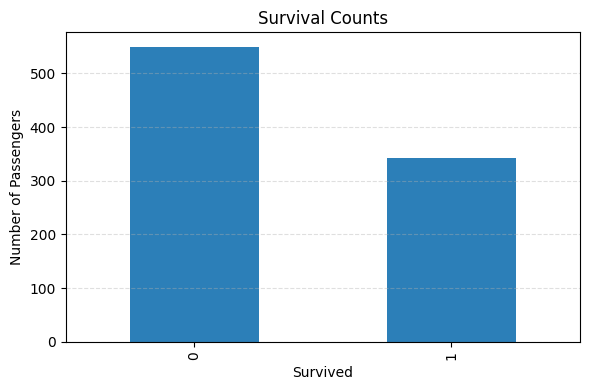

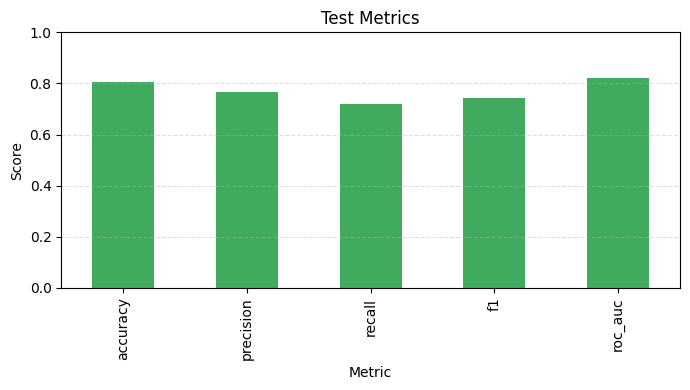

In [ ]:
plt.figure(figsize=(6, 4))
(df[TARGET_COL]
 .value_counts()
 .sort_index()
 .plot(kind='bar', color='#2C7FB8'))
plt.title('Survival Counts')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
(pd.Series(metrics)
 .plot(kind='bar', color='#41AB5D', ylim=(0, 1)))
plt.title('Test Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
